In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nbt import nbt
import base64
import gzip
import io
import re
from tqdm import tqdm
from collections import defaultdict
import xgboost as xgb
from sklearn.model_selection import train_test_split
import xgboost as xgb
import re
from sklearn.metrics import mean_absolute_error, r2_score
import json
import gc
import numba

# Load the mysql database into memory

In [2]:
# 1. Manually find the .env file relative to this notebook
# '..' goes up to src, the second '..' goes up to the root
env_path = Path('../../.env')
load_dotenv(dotenv_path=env_path)

# 2. Now os.getenv will work
USER = os.getenv("MYSQL_USER")
PASSWORD = os.getenv("MYSQL_PASSWORD")
DATABASE = os.getenv("MYSQL_DATABASE")
HOST = "localhost"
HOST = "192.168.86.4"
PORT = "3306"

# 3. Create the engine and load
engine = create_engine(f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

df = pd.read_sql("SELECT * FROM auctions", engine)
print(df)

print(f"Success! Loaded {len(df)} rows.")

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       000080f21c2e4c389b57e1ad1acf431a  22e08a67e5b045ef8f6c2fedd16563f7   
3       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
4       0000bc576d704962a0dfc9d93a3bf12e  ca1b079bc12c48229fd4ad227994e5c4   
...                                  ...                               ...   
452736  fffee76250134299a072e2a743146fec  73e45fa19fce4beab3da3a35bfb6e1fa   
452737  fffef5db947d43e4ae1ee57a67c8ab69  032e4896d71f42a2b96a2b635b27dbb4   
452738  ffff35895c8e4f2d9557fcfd796c0862  1d8badf4062c437a895a4b83c1a4d4fe   
452739  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   
452740  ffffc6391f01414fa8f62cad81e6735a  78664fe51b8041b1aea0c27617f357f4   

                              buyer_uuid  final_price  bin  \
0

In [3]:
def print_all_tags(tag, indent=0):
    """
    Recursively prints all NBT tags and their values.
    """
    prefix = "  " * indent
    
    # If it's a Compound tag (like a folder/dictionary)
    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            print(f"{prefix}{key}:")
            print_all_tags(value, indent + 1)
            
    # If it's a List tag
    elif isinstance(tag, nbt.TAG_List):
        print(f"{prefix}[List of {len(tag)} items]")
        for i, item in enumerate(tag):
            print(f"{prefix}  Index {i}:")
            print_all_tags(item, indent + 2)
            
    # If it's a standard Value tag (String, Int, Byte, etc.)
    else:
        # Clean formatting codes if the value is a string
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        print(f"{prefix}{val}")


def decode_nbt(raw_base64):
    try:
        # 1. Decode Base64
        decoded_data = base64.b64decode(raw_base64)
        
        # 2. Decompress GZip
        uncompressed_data = gzip.decompress(decoded_data)
        
        # 3. Parse NBT
        buffer = io.BytesIO(uncompressed_data)
        nbt_data = nbt.NBTFile(buffer=buffer)
        
        # 4. Navigate to the first item in the list
        # Skyblock/Minecraft auction data usually wraps items in an 'i' list
        items_list = nbt_data["i"]
        return items_list
            
    except Exception as e:
        #print(f"Failed to decode NBT: {e}")
        pass

def decode_and_print_all(raw_base64):
    try:
        items_list = decode_nbt(raw_base64)
        
        for index, item in enumerate(items_list):
            print(f"--- Item #{index} ---")
            print_all_tags(item)
            print("-" * 20)
            
    except Exception as e:
        print(f"Failed to decode NBT: {e}")

## Processing

In [4]:
# Get the raw counts
bin_counts = df['bin'].value_counts()

print("Distribution of Auction Types:")
print(f"BIN (1): {bin_counts.get(1, 0)}")
print(f"Auction (0): {bin_counts.get(0, 0)}")

# Pro-tip: For ML, you often want the percentage/proportion
print("\nProportions:")
print(df['bin'].value_counts(normalize=True))

Distribution of Auction Types:
BIN (1): 445006
Auction (0): 7735

Proportions:
bin
1    0.982915
0    0.017085
Name: proportion, dtype: float64


Seeing as how under 2% of collected auctions were not BIN (Buy It Now), but regular bidding auctions, I have decided to remove these from the training data because in regular auctions, bidding wars occur, where people bid with emotion, not logic, and tend to overpay.


In [5]:
df = df[df['bin'] == 1]
print(df)

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       000080f21c2e4c389b57e1ad1acf431a  22e08a67e5b045ef8f6c2fedd16563f7   
3       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
4       0000bc576d704962a0dfc9d93a3bf12e  ca1b079bc12c48229fd4ad227994e5c4   
...                                  ...                               ...   
452735  fffed6d0c1224f27be3bec5b6a89ac01  ef6719f1e81948979b6fe965d33627c4   
452736  fffee76250134299a072e2a743146fec  73e45fa19fce4beab3da3a35bfb6e1fa   
452737  fffef5db947d43e4ae1ee57a67c8ab69  032e4896d71f42a2b96a2b635b27dbb4   
452738  ffff35895c8e4f2d9557fcfd796c0862  1d8badf4062c437a895a4b83c1a4d4fe   
452739  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   

                              buyer_uuid  final_price  bin  \
0

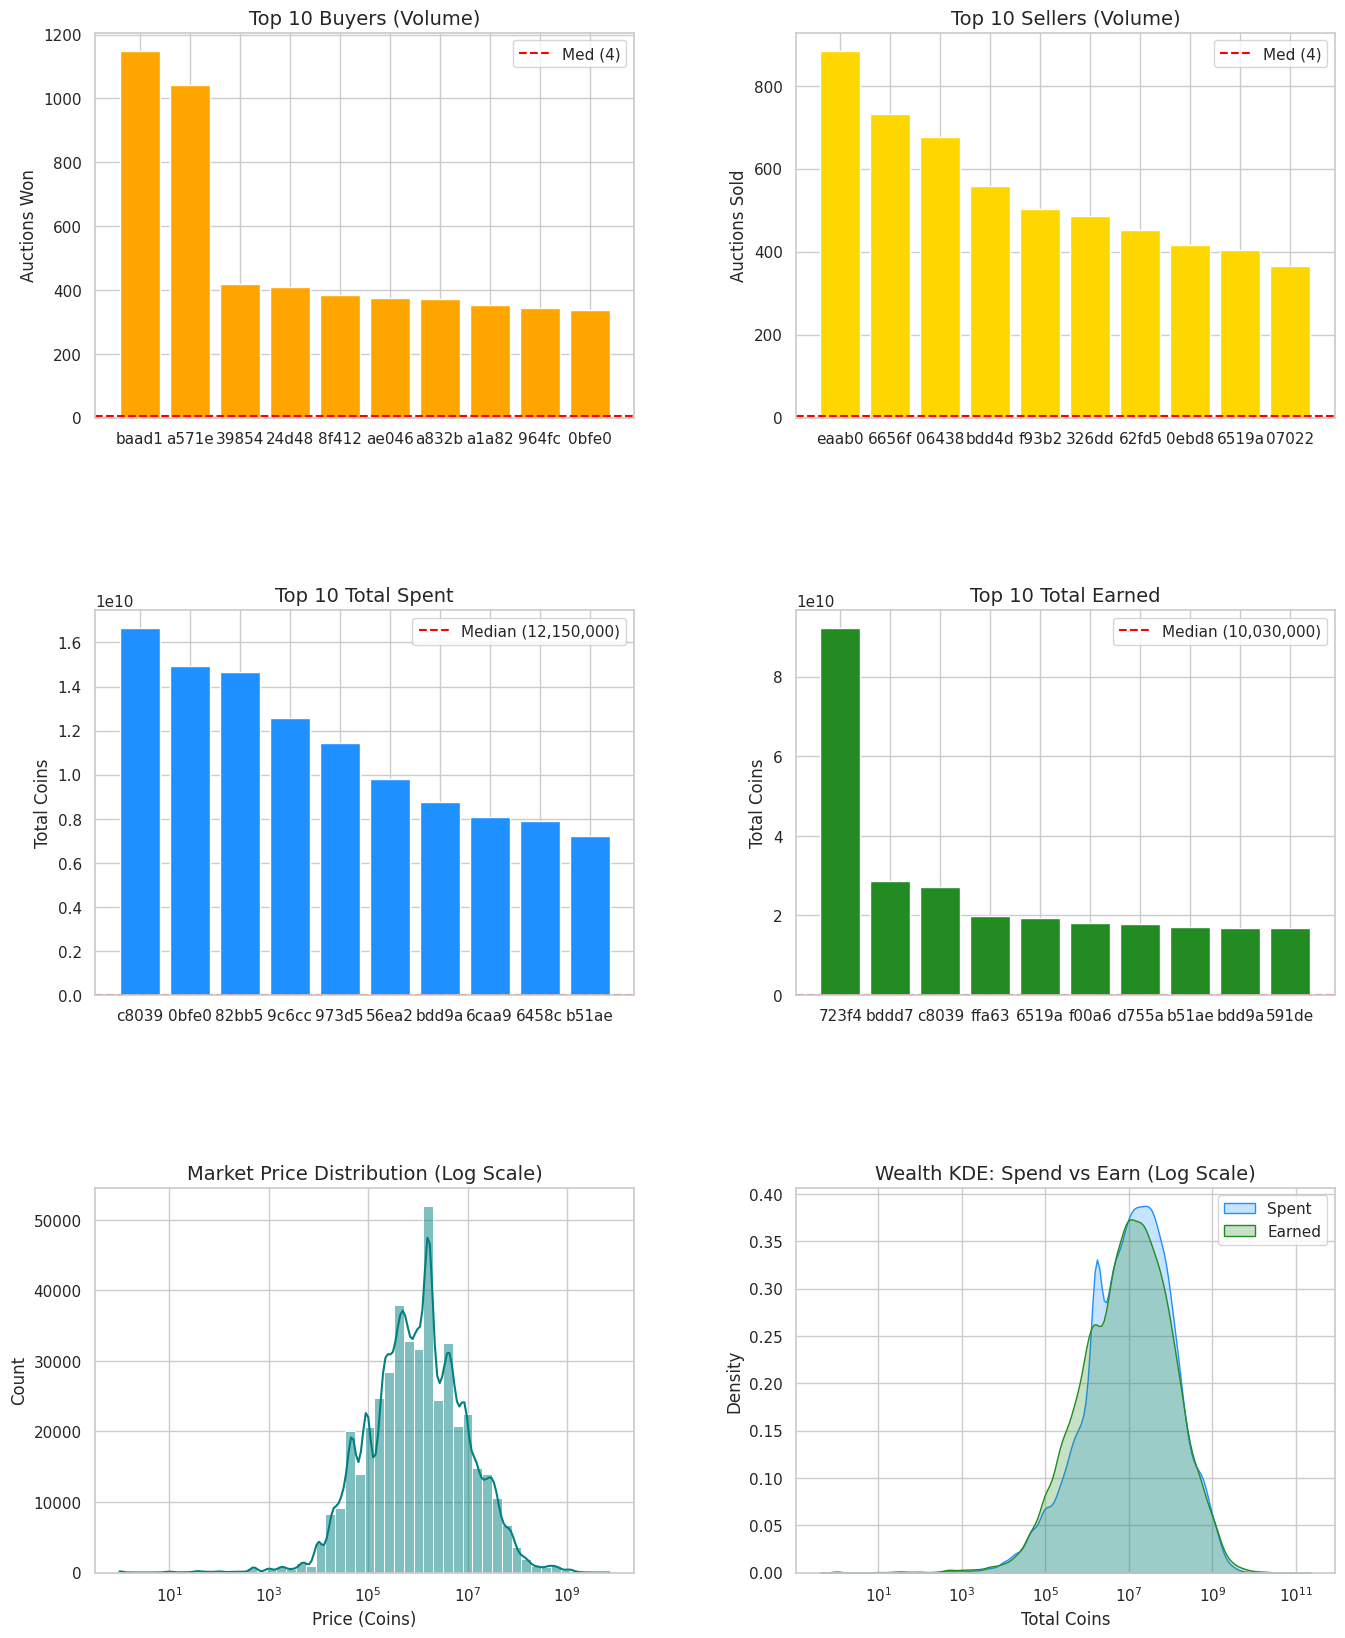

In [6]:
# --- 1. Setup Style & Canvas ---
sns.set_theme(style="whitegrid")
# Using a 3x2 grid to fit all 6 visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# --- ROW 1: VOLUME (TRANSACTION COUNTS) ---

# 1. Top 10 Buyers (Last 5 Chars)
buyer_counts = df['buyer_uuid'].value_counts().head(10)
short_buyer_ids = [str(x)[-5:] for x in buyer_counts.index]
axes[0, 0].bar(short_buyer_ids, buyer_counts.values, color='orange')
median_purchases = df['buyer_uuid'].value_counts().median()
axes[0, 0].axhline(y=median_purchases, color='red', linestyle='--', label=f'Med ({median_purchases:,.0f})')
axes[0, 0].set_title('Top 10 Buyers (Volume)', fontsize=14)
axes[0, 0].set_ylabel('Auctions Won')
axes[0, 0].legend()

# 2. Top 10 Sellers (Last 5 Chars)
seller_counts = df['seller_uuid'].value_counts().head(10)
short_seller_ids = [str(x)[-5:] for x in seller_counts.index]
axes[0, 1].bar(short_seller_ids, seller_counts.values, color='gold')
median_sales = df['seller_uuid'].value_counts().median()
axes[0, 1].axhline(y=median_sales, color='red', linestyle='--', label=f'Med ({median_sales:,.0f})')
axes[0, 1].set_title('Top 10 Sellers (Volume)', fontsize=14)
axes[0, 1].set_ylabel('Auctions Sold')
axes[0, 1].legend()

# --- ROW 2: VALUE (COIN FLOW) ---

# 3. Top 10 Spenders (Last 5 Chars)
spent_per_player = df.groupby('buyer_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_spender_ids = [str(x)[-5:] for x in spent_per_player.index]
axes[1, 0].bar(short_spender_ids, spent_per_player.values, color='dodgerblue')
median_spent = df.groupby('buyer_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 0].axhline(y=median_spent, color='red', linestyle='--', label=f'Median ({median_spent:,.0f})')
axes[1, 0].set_title('Top 10 Total Spent', fontsize=14)
axes[1, 0].set_ylabel('Total Coins')
axes[1, 0].legend()

# 4. Top 10 Earners (Last 5 Chars)
earned_per_player = df.groupby('seller_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_earner_ids = [str(x)[-5:] for x in earned_per_player.index]
axes[1, 1].bar(short_earner_ids, earned_per_player.values, color='forestgreen')
median_earned = df.groupby('seller_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 1].axhline(y=median_earned, color='red', linestyle='--', label=f'Median ({median_earned:,.0f})')
axes[1, 1].set_title('Top 10 Total Earned', fontsize=14)
axes[1, 1].set_ylabel('Total Coins')
axes[1, 1].legend()

# --- ROW 3: GLOBAL DISTRIBUTIONS ---

# 5. Price Distribution (Log Scale)
sns.histplot(df['final_price'], bins=50, kde=True, ax=axes[2, 0], log_scale=True, color='teal')
axes[2, 0].set_title('Market Price Distribution (Log Scale)', fontsize=14)
axes[2, 0].set_xlabel('Price (Coins)')

# 6. Money Spent vs Earned Distribution
full_spent = df.groupby('buyer_uuid')['final_price'].sum()
full_earned = df.groupby('seller_uuid')['final_price'].sum()
sns.kdeplot(full_spent, ax=axes[2, 1], log_scale=True, label='Spent', fill=True, color='dodgerblue')
sns.kdeplot(full_earned, ax=axes[2, 1], log_scale=True, label='Earned', fill=True, color='forestgreen')
axes[2, 1].set_title('Wealth KDE: Spend vs Earn (Log Scale)', fontsize=14)
axes[2, 1].set_xlabel('Total Coins')
axes[2, 1].legend()

plt.show()

In [7]:
sample_row = df.sample(1).iloc[0]

# 2. Pass the specific string to the function
# (No KeyError because sample_row is a Series where 'item_bytes' is a valid key)
decoded_nbt = decode_nbt(sample_row['item_bytes'])

for item in decoded_nbt:
    print(item)

print(decode_and_print_all(sample_row['item_bytes']))

{TAG_Short('id'): 38, TAG_Byte('Count'): 1, TAG_Compound('tag'): {4 Entries}, TAG_Short('Damage'): 4}
--- Item #0 ---
id:
  38
Count:
  1
tag:
  ench:
    [List of 0 items]
  HideFlags:
    254
  display:
    Lore:
      [List of 7 items]
        Index 0:
          Give this to Kat the Pet Sitter in
        Index 1:
          order to skip 1 day of wait time while
        Index 2:
          upgrading your pet!
        Index 3:
          
        Index 4:
          Right-click on Kat to use!
        Index 5:
          
        Index 6:
          SPECIAL
    Name:
      Kat Flower
  ExtraAttributes:
    id:
      KAT_FLOWER
Damage:
  4
--------------------
None


Let's see what all the unique attributes are so we can know what inputs the model will be taking.

In [8]:
# Tags to explicitly ignore
FORBIDDEN_TAGS = {'Lore', 'SkullOwner', 'tags'}

def collect_tag_values(tag, path, results):
    """
    Recursively traverses NBT to find all unique values for each tag path.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            collect_tag_values(value, f"{path}.{key}" if path else key, results)
            
    elif isinstance(tag, nbt.TAG_List):
        # We don't usually need the index in the path for schema discovery
        for item in tag:
            collect_tag_values(item, path, results)
            
    else:
        # It's a leaf node (Value tag)
        val = tag.value
        # Clean string formatting if necessary
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        
        results[path].add(val)


In [ ]:
# Dictionary to hold { "tag_path": {set of unique values} }
tag_schema = defaultdict(set)

print(f"Analyzing NBT for {len(df)} items...")

for raw_nbt in tqdm(df['item_bytes']):
    try:
        # Using your existing decode_nbt logic
        items_list = decode_nbt(raw_nbt)
        for item in items_list:
            collect_tag_values(item, "i", tag_schema)
    except Exception:
        continue

# --- Print the Results ---
print("\n--- NBT Tag Value Discovery ---")
# Sort by path name so it's easy to browse
for path in sorted(tag_schema.keys()):
    values = tag_schema[path]
    num_values = len(values)
    
    print(f"\nTag: {path}")
    print(f"Unique Values: {num_values}")
    
    # If there are few values, show them all. If many, show a sample.
    if num_values <= 15:
        print(f"Values: {values}")
    else:
        sample = list(values)[:10]
        print(f"Sample Values: {sample} ...")

Analyzing NBT for 445006 items...


  0%|          | 1053/445006 [00:00<00:42, 10524.79it/s]

 13%|█▎        | 58384/445006 [00:05<00:36, 10450.48it/s]

In [ ]:
def extract_item_features(tag, path, row_dict):
    """
    Recursively flattens NBT into a flat dictionary for a single item.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            extract_item_features(value, f"{path}.{key}" if path else key, row_dict)
    elif isinstance(tag, nbt.TAG_List):
        for i, item in enumerate(tag):
            # For lists, we just grab the values; complex lists (like enchantments) 
            # often need specific handling, but we'll keep it simple for now.
            extract_item_features(item, f"{path}_{i}", row_dict)
    else:
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        row_dict[path] = val

# 2. Process all auctions into a list of dictionaries
all_features = []
for raw_nbt in tqdm(df['item_bytes'], desc="Flattening NBT"):
    try:
        row_features = {}
        items_list = decode_nbt(raw_nbt)
        # Assuming one item per auction
        extract_item_features(items_list[0], "i", row_features)
        all_features.append(row_features)
    except:
        all_features.append({}) # Keep row alignment even on failure

# 3. Create the massive Feature DataFrame
X_nbt = pd.DataFrame(all_features)

Flattening NBT: 100%|██████████| 443741/443741 [00:40<00:00, 10963.28it/s]


In [ ]:
# 1. Define the threshold (1%)
threshold = 0.0005
total_rows = len(X_nbt)

# 2. Calculate the "Presence Ratio" for every column
# .notna().mean() gives the percentage of non-null values
presence_ratios = X_nbt.notna().mean()

# 3. Identify which columns to keep and which to drop
keep_cols = presence_ratios[presence_ratios >= threshold].index
drop_cols = presence_ratios[presence_ratios < threshold].index

print(f"--- Sparsity Pruning Report ---")
print(f"Total Columns: {len(X_nbt.columns)}")
print(f"Columns to keep: {len(keep_cols)}")
print(f"Columns to drop: {len(drop_cols)}")

# 4. Show a few examples of what we are dropping (the "Rare" tags)
if len(drop_cols) > 0:
    print(f"\nExample tags removed (found in < 1% of auctions):")
    print(list(drop_cols[:10]))

# 5. Modify the DataFrame
X_nbt = X_nbt[keep_cols].copy()

# 6. Manual Memory Cleanup
del drop_cols
del presence_ratios
gc.collect()

print("\nPruning complete. X_nbt updated.")

print(X_nbt.columns)

--- Sparsity Pruning Report ---
Total Columns: 665
Columns to keep: 46
Columns to drop: 619

Example tags removed (found in < 1% of auctions):
['i.tag.ExtraAttributes.gems.DEFENSIVE_0', 'i.tag.ExtraAttributes.gems.DEFENSIVE_0_gem', 'i.tag.ExtraAttributes.enchantments.piercing', 'i.tag.ExtraAttributes.enchantments.infinite_quiver', 'i.tag.ExtraAttributes.enchantments.power', 'i.tag.ExtraAttributes.enchantments.snipe', 'i.tag.ExtraAttributes.enchantments.flame', 'i.tag.ExtraAttributes.enchantments.aiming', 'i.tag.ExtraAttributes.enchantments.punch', 'i.tag.ExtraAttributes.runes.ZOMBIE_SLAYER']

Pruning complete. X_nbt updated.
Index(['i.id', 'i.Count', 'i.tag.Unbreakable', 'i.tag.HideFlags',
       'i.tag.display.color', 'i.tag.display.Name',
       'i.tag.ExtraAttributes.modifier', 'i.tag.ExtraAttributes.upgrade_level',
       'i.tag.ExtraAttributes.id',
       'i.tag.ExtraAttributes.enchantments.rejuvenate',
       'i.tag.ExtraAttributes.enchantments.growth',
       'i.tag.ExtraAttribu

In [ ]:
# 1. Prepare Metadata Features
# Extract time features again to ensure they are aligned with the filtered rows
if 'created_at' in df.columns:
    df['day_of_week'] = df['created_at'].dt.dayofweek
    df['hour_of_day'] = df['created_at'].dt.hour

# 2. Combine Metadata with Pruned NBT Features
# We use .reset_index(drop=True) to ensure the rows match perfectly
X = pd.concat([
    df[['day_of_week', 'hour_of_day']].reset_index(drop=True),
    X_nbt.reset_index(drop=True)
], axis=1)

# We look for the common name paths used in your flattening logic
cols_to_drop = [c for c in X.columns if 'Name' in c or 'display.Name' in c]
print(f"Dropping redundant name columns: {cols_to_drop}")
X = X.drop(columns=cols_to_drop)

# 3. Prepare Target (Log Transformed)
y = np.log1p(df['final_price'].reset_index(drop=True))

# 5. ROBUST TYPE ENFORCEMENT
print("Enforcing dtypes for XGBoost...")
for col in X.columns:
    # If the column is the Item ID or a known categorical string
    if 'id' in col.lower() or 'modifier' in col.lower() or X[col].dtype == 'object':
        X[col] = X[col].astype(str).astype('category')
    else:
        # For everything else, try to make it a float. 
        # If it fails (contains strings), fallback to category safely.
        try:
            X[col] = pd.to_numeric(X[col]).astype('float32')
        except:
            X[col] = X[col].astype(str).astype('category')

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Dropping redundant name columns: ['i.tag.display.Name']
Enforcing dtypes for XGBoost...


In [ ]:

"""
from numba import cuda
# Clear any Python-side references
gc.collect()

# Physically reset the GPU context
try:
    device = cuda.get_current_device()
    device.reset()
    print("GPU context cleared. VRAM should be back to baseline.")
except Exception as e:
    print(f"Reset failed: {e}")
"""

'\nfrom numba import cuda\n# Clear any Python-side references\ngc.collect()\n\n# Physically reset the GPU context\ntry:\n    device = cuda.get_current_device()\n    device.reset()\n    print("GPU context cleared. VRAM should be back to baseline.")\nexcept Exception as e:\n    print(f"Reset failed: {e}")\n'

In [ ]:

import time
print(f"Training on {X_train.shape[0]} rows with {X_train.shape[1]} pruned features...")

model_oracle = xgb.XGBRegressor(
    tree_method="hist",
    device="cpu",             # Using System RAM (62GB) instead of VRAM (12GB)
    n_estimators=6000,        # More trees = better precision
    learning_rate=0.01,       # Slower learning for higher accuracy
    max_depth=12,             # Deep trees to find rare enchant combinations
    subsample=0.8,
    colsample_bytree=1.0,     # USE ALL FEATURES! No more hiding info.
    reg_alpha=1,
    reg_lambda=10,            # High L2 to handle the high feature count
    early_stopping_rounds=100,
    n_jobs=-1                 # Use every CPU core you have
)

print("Starting CPU training (The 62GB RAM 'God Mode')...")
model_oracle.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 7. Evaluation
y_pred_log = model_oracle.predict(X_test)
y_pred_coins = np.expm1(y_pred_log)
y_test_coins = np.expm1(y_test)

print(f"\n--- Oracle Performance (ID Only) ---")
print(f"MAE: {mean_absolute_error(y_test_coins, y_pred_coins):,.0f} coins")
print(f"R2 Score: {r2_score(y_test, y_pred_log):.4f}")

# 9. Save the Final Oracle
path = f"../models/skyblock_oracle_{int(time.time())}.json"
model_oracle.save_model()
print("Oracle saved to .json")

Training on 354992 rows with 47 pruned features...
Starting CPU training (The 62GB RAM 'God Mode')...


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:i.id: category, i.tag.HideFlags: category, i.tag.ExtraAttributes.modifier: category, i.tag.ExtraAttributes.id: category, i.tag.ExtraAttributes.uuid: category, i.tag.ExtraAttributes.timestamp: category, i.tag.ExtraAttributes.dungeon_skill_req: category, i.tag.ench_0.id: category, i.tag.ExtraAttributes.bossId: category, i.tag.ExtraAttributes.spawnedFor: category, i.tag.ExtraAttributes.petInfo: category, i.tag.ExtraAttributes.originTag: category, i.tag.ExtraAttributes.gems.unlocked_slots_0: category, i.tag.ExtraAttributes.gems.unlocked_slots_1: category, i.tag.ExtraAttributes.enchantments.depth_strider: category, i.tag.ExtraAttributes.backpack_color: category